In [1]:
# 3rd party
%pylab inline
from tqdm import tqdm
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.stats import norm

# Local
import plotting

Populating the interactive namespace from numpy and matplotlib


In [2]:
import global_imports
c = global_imports._c
G = global_imports._G
Msun = global_imports._M_s
pi = global_imports._pi
rho_ns = global_imports._rhons


c_dark_energy = plotting.c_dark_energy
c_bosonic = plotting.c_bosonic
c_fermionic= plotting.c_fermionic
c_baryonic = plotting.c_baryonic[1]

In [3]:
10**(14.75)/rho_ns

densities = np.logspace(14.2,16,50) / rho_ns

print(densities)

[ 0.59139129  0.64359049  0.70039705  0.76221766  0.82949486  0.90271029
  0.98238808  1.06909865  1.16346272  1.26615585  1.3779132   1.49953482
  1.63189138  1.77593041  1.93268305  2.10327147  2.28891689  2.49094833
  2.71081208  2.95008213  3.21047136  3.49384387  3.80222828  4.13783226
  4.50305836  4.90052117  5.33306606  5.80378956  6.31606151  6.87354919
  7.48024356  8.14048785  8.85900867  9.64094978 10.49190898 11.41797817
 12.42578692 13.52255    14.71611896 16.01503838 17.42860702 18.96694442
 20.64106328 22.46294839 24.44564232 26.6033389  28.95148474 31.50688986
 34.28784801 37.31426766]


In [4]:
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)

pyplot.rc('text', usetex=True)
pyplot.rc('font', family='serif')

pyplot.rcParams['xtick.direction'] = 'in'
pyplot.rcParams['xtick.minor.visible'] = True
pyplot.rcParams['ytick.direction'] = 'in'
pyplot.rcParams['ytick.minor.visible'] = True
pyplot.rcParams['xtick.major.size'] = 5
pyplot.rcParams['ytick.major.size'] = 5
pyplot.rcParams['ytick.right'] = True
pyplot.rcParams['xtick.top'] = True

In [15]:

chirp_mass = [None,None]
number_stars = len(chirp_mass)
variable_params = {'gamma1':[1., 4.5], 'gamma2':[0., 8.], 'gamma3':[0.5, 8.], 'rho_t1':[1.5, 8.3], 'rho_t2':[1.5, 8.3],
                  'A_param':[0.1, 0.7],'rho_plus': [1.1,37.3142677],'alpha':[0.1, 1.],'ceft':[1, 3]}
# variable_params.update({'ceft':[EOS.min_norm, EOS.max_norm]})
#variable_params = {'mchi':[-2, 9],'gchi_over_mphi': [-5,3],'adm_fraction':[0., 1.7]}
for i in range(number_stars):
	variable_params.update({'rhoc_' + str(i+1):[14.6, 16]})



#static_params = {'gamma1': 2.3, 'gamma2': 4., 'gamma3': 2.6, 'rho_t1': 1.8, 'rho_t2': 4., 'ceft': 2.6}
static_params = {}

In [16]:
def eos_interpolator_de(ewposterior):
    pressure_2n0 = np.zeros(len(ewposterior))
    pressure_15n0 = np.zeros(len(ewposterior))
    for i in tqdm(range(0,len(ewposterior),1)):
        pr = ewposterior[i][0:len(variable_params)]
        par = {e:pr[j] for j, e in enumerate(list(variable_params.keys()))}
        par.update(static_params)
        EOS.update(par, max_edsc_de=False, max_edsc = True)

        eps015 = 1.5*rho_ns
        eps020 = 2.0*rho_ns
        if (EOS.rho_plus/rho_ns < 1.5):
            pressure_15n0[i] = EOS.eos_de(eps015) 
            pressure_2n0[i] = EOS.eos_de(eps020)
        if(EOS.rho_plus/rho_ns < 2.0 and EOS.rho_plus/rho_ns > 1.5):
            pressure_15n0[i] = EOS.eos(eps015)
            pressure_2n0[i] =  EOS.eos_de(eps020)
        if(EOS.rho_plus/rho_ns > 2.0):
            pressure_15n0[i] = EOS.eos(eps015)
            pressure_2n0[i] = EOS.eos(eps020)
            

    pressure_2n0 = pressure_2n0[pressure_2n0>0.]
    pressure_15n0 = pressure_15n0[pressure_15n0>0.]
    return pressure_15n0,pressure_2n0

In [17]:
run_name = 'DE/Dark_energy_posterior_'
ewposterior = np.loadtxt('DE/Dark_energy_posterior_post_equal_weights.dat')
pressn15, pressn20 = eos_interpolator_de(ewposterior)


  0%|          | 0/18192 [00:00<?, ?it/s]


NameError: name 'EOS' is not defined

In [ ]:
fname = run_name + 'press_n15_other_way.npy'
print(f'Saving pressures at 1.5 n_0 to {fname}')
np.save(fname, pressn15)


fname = run_name + 'press_n20_other_way.npy'
print(f'Saving pressures at 2.0 n_0 to {fname}')
np.save(fname, pressn20)

In [6]:
def eos_interpolator(pressures):
    num_eos = len(pressures[0])
    pressure_2n0 = np.zeros(len(pressures[0]))
    pressure_15n0 = np.zeros(len(pressures[0]))
    for i in tqdm(range(0,len(pressures[0]),1)):
        #densities for dark matter should be 250, so it should be the length of the pressure column
        densities = np.logspace(14.2,16,len(pressures[:,i])) / rho_ns # in units of rho_ns (effectively a ratio w.r.t saturation mass density)
        nonzero_indices = np.nonzero(pressures[:,i])[0]
        p = pressures[:,i]

        p = p[nonzero_indices] # only grab non-zero values
        densities = densities[nonzero_indices]
        try:
            p_dens =UnivariateSpline(densities, p, k=1, s=0, ext=1) # requires x to be strictly increasing, but a much faster function than interp1d, so we prefer to use it
            pressure_2n0[i] = p_dens(2.)
            pressure_15n0[i] = p_dens(1.5)
        except ValueError:
            raise Warning("densities is not strictly increasing! Switching to slower interp1d() function")
            p_dens = interp1d(densities, p, kind='linear', fill_value= [0.],bounds_error = False) #back-up interpolator in the event x is not strictly increasing (Safety net)
            pressure_2n0[i] = p_dens(2.)                                                        
            pressure_15n0[i] = p_dens(1.5)

    pressure_2n0 = pressure_2n0[pressure_2n0>0.]
    pressure_15n0 = pressure_15n0[pressure_15n0>0.]
    return pressure_15n0,pressure_2n0

In [7]:
run_name = 'BDM/Bosonic_posterior_'
pressures = np.load(run_name + 'pressures.npy')
pressn15, pressn20 = eos_interpolator(pressures)

# print(pressn15)
# print(pressn20)

fname = run_name + 'press_n15.npy'
print(f'Saving pressures at 1.5 n_0 to {fname}')
np.save(fname, pressn15)

fname = run_name + 'press_n20.npy'
print(f'Saving pressures at 2.0 n_0 to {fname}')
np.save(fname, pressn20)

100%|██████████| 18172/18172 [00:01<00:00, 13284.34it/s]

Saving pressures at 1.5 n_0 to BDM/Bosonic_posterior_press_n15.npy
Saving pressures at 2.0 n_0 to BDM/Bosonic_posterior_press_n20.npy


In [8]:
run_name = 'B/Baryonic_posterior_'
pressures = np.load(run_name + 'pressures.npy')
pressn15, pressn20 = eos_interpolator(pressures)

# print(pressn15)
# print(pressn20)

fname = run_name + 'press_n15.npy'
print(f'Saving pressures at 1.5 n_0 to {fname}')
np.save(fname, pressn15)

fname = run_name + 'press_n20.npy'
print(f'Saving pressures at 2.0 n_0 to {fname}')
np.save(fname, pressn20)

100%|██████████| 18167/18167 [00:01<00:00, 15220.50it/s]

Saving pressures at 1.5 n_0 to B/Baryonic_posterior_press_n15.npy
Saving pressures at 2.0 n_0 to B/Baryonic_posterior_press_n20.npy


In [9]:
run_name = 'FDM/Fermionic_posterior_'
pressures = np.load(run_name + 'pressures.npy')
pressn15, pressn20 = eos_interpolator(pressures)

fname = run_name + 'press_n15.npy'
print(f'Saving pressures at 1.5 n_0 to {fname}')
np.save(fname, pressn15)

fname = run_name + 'press_n20.npy'
print(f'Saving pressures at 2.0 n_0 to {fname}')
np.save(fname, pressn20)

100%|██████████| 18121/18121 [00:01<00:00, 13370.21it/s]

Saving pressures at 1.5 n_0 to FDM/Fermionic_posterior_press_n15.npy
Saving pressures at 2.0 n_0 to FDM/Fermionic_posterior_press_n20.npy


FileNotFoundError: [Errno 2] No such file or directory: 'DE/Dark_energy_posterior_press_n15.npy'

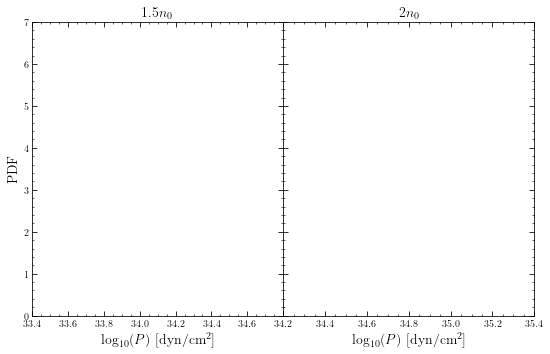

In [11]:
def plot(ax, y, colors, priors=False, face_alpha=None):
    lw = 0.5
    if priors is True:
        ax.hist(np.log10(y[y>0.]), bins=20, density=True, histtype='step', linestyle='-', color=colors, alpha=0.8, lw=lw)
    else:
        ax.hist(np.log10(y[y>0]), bins=20, density=True, histtype='stepfilled', facecolor=colors, alpha=face_alpha)
        ax.hist(np.log10(y[y>0]), bins=20, density=True,  histtype='step',color=colors, alpha=1.0, lw=0.4)

# Paths
# current_path = os.path.dirname(__file__)
# parent = os.path.dirname(current_path)

# Create subplots, remove spaces
width = 9
height = 5.4
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(width,height))
fig.subplots_adjust(wspace=0, hspace=0)

face_alpha = 0.7


# Set axis limits and ticks
# axes[1].set_yticks([])

xticks1 = [33.4, 33.6, 33.8,34.0, 34.2, 34.4, 34.6]
xticks2 = [34.2, 34.4, 34.6, 34.8, 35.0, 35.2, 35.4]
axes[0].set_xticks(xticks1)
axes[1].set_xticks(xticks2)
# axes[1,0].set_xticks(xticks2[:-1])
# axes[1,1].set_xticks(xticks2)
axes[0].set_xticklabels(xticks1)
axes[1].set_xticklabels(xticks2)
# axes[1,0].set_xticklabels(xticks2[:-1])
# axes[1,1].set_xticklabels(xticks2)

xlim1 = (33.4, 34.8)
xlim2 = (34.2, 35.4)

axes[0].set_xlim(xlim1)
axes[1].set_xlim(xlim2)
ymax = 7.0
axes[0].set_ylim(0,ymax)

# Set labels and titles
ylabel = 'PDF'
xlabel = r'$\log_{10}(P)$ [dyn/cm$^2$]'
axes[0].set_xlabel(xlabel,fontsize = 14)
axes[1].set_xlabel(xlabel,fontsize = 14)
axes[0].set_ylabel(ylabel,fontsize = 14)
axes[0].set_title(f'$1.5 n_0$',fontsize = 14) #[0,0]
axes[1].set_title(f'$2 n_0$',fontsize = 14) #[0,1]



##################################### fix this
DE_posterior_path = 'DE/Dark_energy_posterior_'
Bosonic_posterior_path = 'BDM/Bosonic_posterior_'
Fermionic_posterior_path = 'FDM/Fermionic_posterior_'
Baryonic_posterior_path = 'B/Baryonic_posterior_'


# DE_pressure_15 = np.load(DE_posterior_path+ 'press_n15.npy')
# DE_pressure_20 = np.load(DE_posterior_path+ 'press_n20.npy')

DE_pressure_15ot = np.load(DE_posterior_path+ 'press_n15.npy')
DE_pressure_20ot = np.load(DE_posterior_path+ 'press_n20.npy')

Bosonic_pressure_15 = np.load(Bosonic_posterior_path+ 'press_n15.npy')
Bosonic_pressure_20 = np.load(Bosonic_posterior_path+ 'press_n20.npy')

Fermionic_pressure_15 = np.load(Fermionic_posterior_path+ 'press_n15.npy')
Fermionic_pressure_20 = np.load(Fermionic_posterior_path+ 'press_n20.npy')

Baryonic_pressure_15 = np.load(Baryonic_posterior_path+ 'press_n15.npy')
Baryonic_pressure_20 = np.load(Baryonic_posterior_path+ 'press_n20.npy')

DE_prior_path = 'DE/Dark_energy_prior_'
BDM_prior_path = 'DE/Dark_energy_prior_'
FDM_prior_path = 'DE/Dark_energy_prior_'
B_prior_path = 'DE/Dark_energy_prior_'
# prior_pressure_11_2_pp = np.load(f'{prior_path}/pp/{order_lower}/11/press_n20.npy')
# prior_pressure_11_2_cs = np.load(f'{prior_path}/cs/{order_lower}/11/press_n20.npy')

# prior_pressure_15_2_pp = np.load(f'{prior_path}/pp/{order_lower}/15/press_n20.npy')
# prior_pressure_15_2_cs = np.load(f'{prior_path}/cs/{order_lower}/15/press_n20.npy')

# prior_pressure_11_3_pp = np.load(f'{prior_path}/pp/{order_lower}/11/press_n30.npy')
# prior_pressure_11_3_cs = np.load(f'{prior_path}/cs/{order_lower}/11/press_n30.npy')

# prior_pressure_15_3_pp = np.load(f'{prior_path}/pp/{order_lower}/15/press_n30.npy')
# prior_pressure_15_3_cs = np.load(f'{prior_path}/cs/{order_lower}/15/press_n30.npy')
############################################

# 1.5 n_0
ax = axes[0]
# plot(ax, DE_pressure_15, c_dark_energy, face_alpha=face_alpha)
# plot(ax, prior_pressure_11_2_pp, c_n2lo[1], True, face_alpha=face_alpha)

plot(ax, DE_pressure_15ot, c_dark_energy, face_alpha=face_alpha)


plot(ax, Bosonic_pressure_15, c_bosonic, face_alpha=face_alpha)
# plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)

plot(ax, Fermionic_pressure_15, c_fermionic, face_alpha=face_alpha)
# plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)

plot(ax, Baryonic_pressure_15, c_baryonic, face_alpha=face_alpha)
# plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)

# 2 n_0
ax = axes[1]
plot(ax, DE_pressure_20ot, c_dark_energy, face_alpha=face_alpha)
# # plot(ax, prior_pressure_11_2_pp, c_n2lo[1], True, face_alpha=face_alpha)

plot(ax, Bosonic_pressure_20, c_bosonic, face_alpha=face_alpha)
# # plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)

plot(ax, Fermionic_pressure_20, c_fermionic, face_alpha=face_alpha)
# # plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)

plot(ax, Baryonic_pressure_20, c_baryonic, face_alpha=face_alpha)
# # plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)



# Add text
ax = axes
x = 0.04
y = 0.89
y2 = 0.79
# txt = f'$n = 2 n_0$'
# axes[0].text(x, y, txt, transform=axes[0].transAxes)

# txt = f'$n = 3 n_0$'
# axes[1].text(x, y, txt, transform=axes[1].transAxes)


# Minor ticks
axes[0].minorticks_on()
axes[1].minorticks_on()
# axes[0].tick_params(which='both', direction='in', labelsize=13)
# axes[1].tick_params(which='both', direction='in', labelsize=13)
# Z-order the panels. Needed for the ticks to show up properly
# Right on top of left, top on top of bottom.
# axes[1,0].set_zorder(1)
# axes[1,1].set_zorder(2)
# axes[0].set_zorder(3)
# axes[1].set_zorder(4)

# Add legends
#line0 = plotting.custom_line('xkcd:black', '-', lw=0.6) #prior when you get to it
line1 = plotting.custom_patch(c_dark_energy, alpha=face_alpha)
line2 = plotting.custom_patch(c_bosonic, alpha=face_alpha)
line3 = plotting.custom_patch(c_fermionic, alpha=face_alpha)
line4 = plotting.custom_patch(c_baryonic, alpha=face_alpha)
custom_lines = [line1, line2, line3, line4]
labels = ['CDF + Baryonic EoS', 'Bosonic ADM + Baryonic EoS', 'Fermionic ADM + Baryonic EoS', 'Baryonic EoS']
loc = (0.05,0.70)
axes[1].legend(custom_lines, labels, loc=loc, frameon=False, fontsize = 12)

ax[0].tick_params(top=1,right=1, which='both', direction='in', labelsize=14)
ax[1].tick_params(top=1,right=1, which='both', direction='in', labelsize=14)

# custom_lines = [line0, line2, line3, line4]
# axes[1,1].legend(custom_lines, labels, loc=loc, frameon=False)
plt.show()
fig.savefig('plots/Pressures_histograms_all.pdf',bbox_inches = 'tight')
# Save result
# string = '_N2LO' if order_lower == 'n2lo' else ''
# plotting.save(fig, f'{parent}/fig', f'pressure_new_histograms{string}.pdf', args.tmp_output)


def plot(ax, y, colors, priors=False, face_alpha=None):
    lw = 0.5
    if priors is True:
        ax.hist(np.log10(y[y>0.]), bins=20, density=True, histtype='step', linestyle='-', color=colors, alpha=0.8, lw=lw)
    else:
        ax.hist(np.log10(y[y>0]), bins=20, density=True, histtype='stepfilled', facecolor=colors, alpha=face_alpha)
        ax.hist(np.log10(y[y>0]), bins=20, density=True,  histtype='step',color=colors, alpha=1.0, lw=0.4)

# Paths
# current_path = os.path.dirname(__file__)
# parent = os.path.dirname(current_path)

# Create subplots, remove spaces
width = 10
height = 5.4
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(width,height))
fig.subplots_adjust(wspace=0, hspace=0)

face_alpha = 0.7


# Set axis limits and ticks
# axes[1].set_yticks([])

xticks1 = [33.4, 33.6, 33.8,34.0, 34.2, 34.4, 34.6]
xticks2 = [34.2, 34.4, 34.6, 34.8, 35.0, 35.2, 35.4]
axes[0].set_xticks(xticks1)
axes[1].set_xticks(xticks2)
# axes[1,0].set_xticks(xticks2[:-1])
# axes[1,1].set_xticks(xticks2)
axes[0].set_xticklabels(xticks1)
axes[1].set_xticklabels(xticks2)
# axes[1,0].set_xticklabels(xticks2[:-1])
# axes[1,1].set_xticklabels(xticks2)

xlim1 = (33.4, 34.8)
xlim2 = (34.2, 35.4)

axes[0].set_xlim(xlim1)
axes[1].set_xlim(xlim2)
ymax = 7.0
axes[0].set_ylim(0,ymax)

# Set labels and titles
ylabel = 'PDF'
xlabel = r'$\log_{10}(P)$ [dyn/cm$^2$]'
axes[0].set_xlabel(xlabel,fontsize = 14)
axes[1].set_xlabel(xlabel,fontsize = 14)
axes[0].set_ylabel(ylabel,fontsize = 14)
axes[0].set_title(f'$1.5 n_0$',fontsize = 14) #[0,0]
axes[1].set_title(f'$2 n_0$',fontsize = 14) #[0,1]



##################################### fix this
DE_posterior_path = 'DE/Dark_energy_posterior_'
Bosonic_posterior_path = 'BDM/Bosonic_posterior_'
Fermionic_posterior_path = 'FDM/Fermionic_posterior_'
Baryonic_posterior_path = 'B/Baryonic_posterior_'


# DE_pressure_15 = np.load(DE_posterior_path+ 'press_n15.npy')
# DE_pressure_20 = np.load(DE_posterior_path+ 'press_n20.npy')

DE_pressure_15ot = np.load(DE_posterior_path+ 'press_n15_other_way.npy')
DE_pressure_20ot = np.load(DE_posterior_path+ 'press_n20_other_way.npy')

Bosonic_pressure_15 = np.load(Bosonic_posterior_path+ 'press_n15.npy')
Bosonic_pressure_20 = np.load(Bosonic_posterior_path+ 'press_n20.npy')

Fermionic_pressure_15 = np.load(Fermionic_posterior_path+ 'press_n15.npy')
Fermionic_pressure_20 = np.load(Fermionic_posterior_path+ 'press_n20.npy')

Baryonic_pressure_15 = np.load(Baryonic_posterior_path+ 'press_n15.npy')
Baryonic_pressure_20 = np.load(Baryonic_posterior_path+ 'press_n20.npy')

DE_prior_path = 'DE/Dark_energy_prior_'
BDM_prior_path = 'DE/Dark_energy_prior_'
FDM_prior_path = 'DE/Dark_energy_prior_'
B_prior_path = 'DE/Dark_energy_prior_'
# prior_pressure_11_2_pp = np.load(f'{prior_path}/pp/{order_lower}/11/press_n20.npy')
# prior_pressure_11_2_cs = np.load(f'{prior_path}/cs/{order_lower}/11/press_n20.npy')

# prior_pressure_15_2_pp = np.load(f'{prior_path}/pp/{order_lower}/15/press_n20.npy')
# prior_pressure_15_2_cs = np.load(f'{prior_path}/cs/{order_lower}/15/press_n20.npy')

# prior_pressure_11_3_pp = np.load(f'{prior_path}/pp/{order_lower}/11/press_n30.npy')
# prior_pressure_11_3_cs = np.load(f'{prior_path}/cs/{order_lower}/11/press_n30.npy')

# prior_pressure_15_3_pp = np.load(f'{prior_path}/pp/{order_lower}/15/press_n30.npy')
# prior_pressure_15_3_cs = np.load(f'{prior_path}/cs/{order_lower}/15/press_n30.npy')
############################################

# 1.5 n_0
ax = axes[0]
# plot(ax, DE_pressure_15, c_dark_energy, face_alpha=face_alpha)
# plot(ax, prior_pressure_11_2_pp, c_n2lo[1], True, face_alpha=face_alpha)

plot(ax, DE_pressure_15ot, c_dark_energy, face_alpha=face_alpha)


plot(ax, Bosonic_pressure_15, c_bosonic, face_alpha=face_alpha)
# plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)

plot(ax, Fermionic_pressure_15, c_fermionic, face_alpha=face_alpha)
# plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)

plot(ax, Baryonic_pressure_15, c_baryonic, face_alpha=face_alpha)
# plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)

# 2 n_0
ax = axes[1]
plot(ax, DE_pressure_20ot, c_dark_energy, face_alpha=face_alpha)
# # plot(ax, prior_pressure_11_2_pp, c_n2lo[1], True, face_alpha=face_alpha)

plot(ax, Bosonic_pressure_20, c_bosonic, face_alpha=face_alpha)
# # plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)

plot(ax, Fermionic_pressure_20, c_fermionic, face_alpha=face_alpha)
# # plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)

plot(ax, Baryonic_pressure_20, c_baryonic, face_alpha=face_alpha)
# # plot(ax, prior_pressure_15_2_pp, c_n3lo[1], True, face_alpha=face_alpha)



# Add text
ax = axes
x = 0.04
y = 0.89
y2 = 0.79
# txt = f'$n = 2 n_0$'
# axes[0].text(x, y, txt, transform=axes[0].transAxes)

# txt = f'$n = 3 n_0$'
# axes[1].text(x, y, txt, transform=axes[1].transAxes)


# Minor ticks
axes[0].minorticks_on()
axes[1].minorticks_on()
# axes[0].tick_params(which='both', direction='in', labelsize=13)
# axes[1].tick_params(which='both', direction='in', labelsize=13)
# Z-order the panels. Needed for the ticks to show up properly
# Right on top of left, top on top of bottom.
# axes[1,0].set_zorder(1)
# axes[1,1].set_zorder(2)
# axes[0].set_zorder(3)
# axes[1].set_zorder(4)

# Add legends
#line0 = plotting.custom_line('xkcd:black', '-', lw=0.6) #prior when you get to it
line1 = plotting.custom_patch(c_dark_energy, alpha=face_alpha)
line2 = plotting.custom_patch(c_bosonic, alpha=face_alpha)
line3 = plotting.custom_patch(c_fermionic, alpha=face_alpha)
line4 = plotting.custom_patch(c_baryonic, alpha=face_alpha)
custom_lines = [line1, line2, line3, line4]
labels = ['CDF + Baryonic EoS', 'Bosonic ADM + Baryonic EoS', 'Fermionic ADM + Baryonic EoS', 'Baryonic EoS']
loc = (0.05,0.70)
axes[1].legend(custom_lines, labels, loc=loc, frameon=False, fontsize = 14)

ax[0].tick_params(top=1,right=1, which='both', direction='in', labelsize=14)
ax[1].tick_params(top=1,right=1, which='both', direction='in', labelsize=14)

# custom_lines = [line0, line2, line3, line4]
# axes[1,1].legend(custom_lines, labels, loc=loc, frameon=False)
plt.show()
fig.savefig('plots/Pressures_histograms_all.pdf',bbox_inches = 'tight')